# Random Forest Model — Depression Target with Class Balancing

This notebook trains a **Random Forest classifier** to predict the binary target column `Depression`.

## Why this version is updated
The dataset is highly imbalanced:

- most students are labelled `False` for depression
- fewer students are labelled `True`

This means plain accuracy can be misleading, because a model can get high accuracy by mostly predicting the majority class.

To account for this, this model uses:

```python
class_weight="balanced"
```

This gives more weight to the minority class during training.


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

# Change this file name if needed
csv_file = "student_lifestyle_100k.csv"

df = pd.read_csv(csv_file)

df.head()


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [3]:
# ============================================================
# 3. CHECK TARGET DISTRIBUTION
# ============================================================

target = "Depression"

print("Target value counts:")
print(df[target].value_counts())

print("\nTarget proportions:")
print(df[target].value_counts(normalize=True))


Target value counts:
Depression
False    89938
True     10062
Name: count, dtype: int64

Target proportions:
Depression
False    0.89938
True     0.10062
Name: proportion, dtype: float64


### What this shows
This checks whether the dataset is balanced.

If one class is much more common than the other, accuracy alone is not enough to judge model performance.


In [4]:
# ============================================================
# 4. DEFINE FEATURES AND TARGET
# ============================================================

# Drop ID-like columns because they should not help prediction
id_like_columns = [col for col in df.columns if "id" in col.lower()]
print("Dropping ID-like columns:", id_like_columns)

df_model = df.drop(columns=id_like_columns)

# X = input features
# y = output target
X = df_model.drop(columns=[target])
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target:", target)


Dropping ID-like columns: ['Student_ID']
X shape: (100000, 9)
y shape: (100000,)
Target: Depression


In [5]:
# ============================================================
# 5. IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ============================================================

categorical_cols = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)


Categorical columns:
['Gender', 'Department']

Numerical columns:
['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']


In [6]:
# ============================================================
# 6. PREPROCESSING PIPELINE
# ============================================================

# Numerical features:
# - replace missing values with median
#
# Categorical features:
# - replace missing values with most common category
# - convert categories into numerical 0/1 columns using one-hot encoding

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numerical_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)


In [7]:
# ============================================================
# 7. SEQUENTIAL 70/30 TRAIN/TEST SPLIT
# ============================================================

n = len(X)
split_index = int(0.7 * n)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True))


Training set shape: (70000, 9)
Testing set shape: (30000, 9)

Training target proportions:
Depression
False    0.898829
True     0.101171
Name: proportion, dtype: float64

Testing target proportions:
Depression
False    0.900667
True     0.099333
Name: proportion, dtype: float64


## Updated Random Forest model

The important change is:

```python
class_weight="balanced"
```

This tells the model to give more importance to the minority class (`True`) instead of being dominated by the majority class (`False`).


In [8]:
# ============================================================
# 8. TRAIN BALANCED RANDOM FOREST MODEL
# ============================================================

model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

print("Balanced Random Forest model training complete.")


Balanced Random Forest model training complete.


In [9]:
# ============================================================
# 9. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print("Class order:")
print(model.named_steps["rf"].classes_)


Class order:
[False  True]


In [10]:
# ============================================================
# 10. EVALUATE MODEL
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

majority_class = y_train.value_counts().idxmax()
baseline_pred = [majority_class] * len(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8660
Balanced Accuracy: 0.5509
Majority-class baseline accuracy: 0.9007

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.94      0.93     27020
        True       0.24      0.16      0.19      2980

    accuracy                           0.87     30000
   macro avg       0.57      0.55      0.56     30000
weighted avg       0.84      0.87      0.85     30000



### How to interpret this output
For this imbalanced dataset, do not only focus on accuracy.

Important values to look at are:

- **Recall for True**: how many actually depressed students were correctly identified
- **F1-score for True**: balance of precision and recall for the depressed class
- **Balanced accuracy**: average performance across both classes
- **ROC AUC**: how well the model separates depressed from non-depressed students


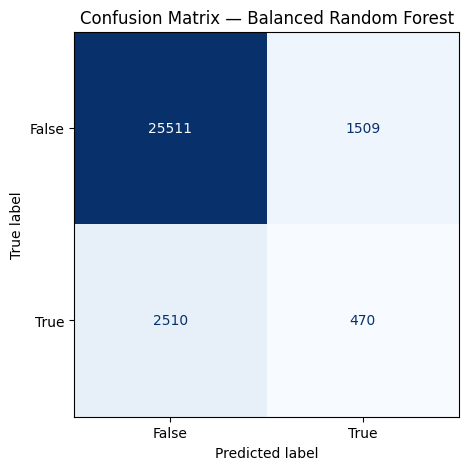

In [11]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

classes = list(model.named_steps["rf"].classes_)

cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion Matrix — Balanced Random Forest")
plt.show()


Binary ROC AUC: 0.7008


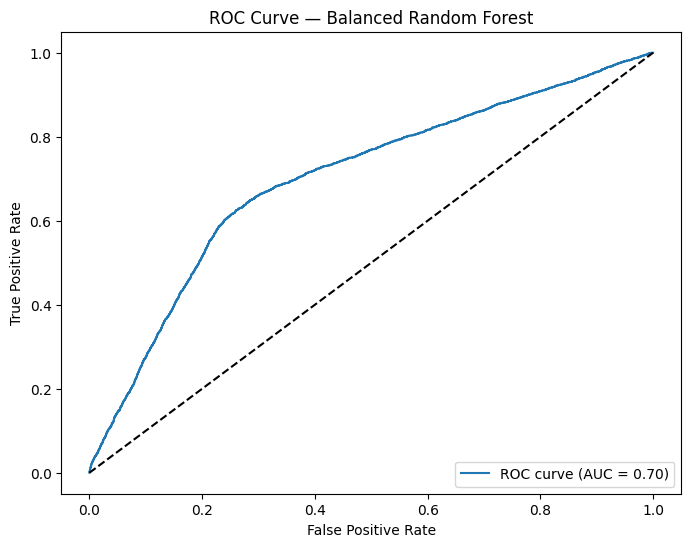

In [12]:
# ============================================================
# 12. ROC AUC AND ROC CURVE
# ============================================================

# For binary classification, use the probability of the positive class.
# The positive class here should be True.
classes = list(model.named_steps["rf"].classes_)
positive_class_index = classes.index(True)

positive_probabilities = y_proba[:, positive_class_index]

roc_auc = roc_auc_score(y_test, positive_probabilities)

print(f"Binary ROC AUC: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, positive_probabilities, pos_label=True)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Balanced Random Forest")
plt.legend(loc="lower right")
plt.show()


Results using threshold = 0.3
--------------------------------
Accuracy: 0.7591
Balanced Accuracy: 0.6710

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.78      0.85     27020
        True       0.22      0.56      0.32      2980

    accuracy                           0.76     30000
   macro avg       0.58      0.67      0.59     30000
weighted avg       0.87      0.76      0.80     30000



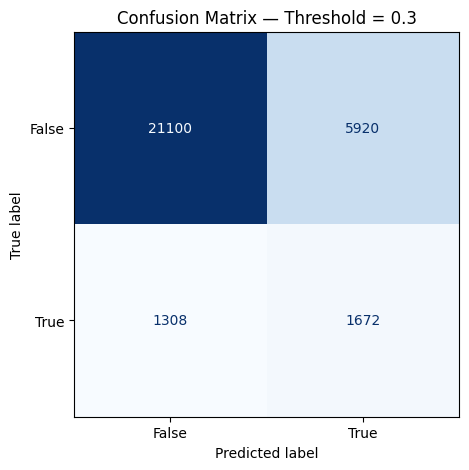

In [13]:
# ============================================================
# 13. OPTIONAL: CHANGE DECISION THRESHOLD
# ============================================================

# Random Forest usually predicts True only if probability >= 0.5.
# With imbalanced data, this can still miss many True cases.
#
# This cell lets you test a lower threshold.
# Lower threshold = more True predictions = usually higher recall but lower precision.

threshold = 0.30

y_pred_threshold = positive_probabilities >= threshold

print(f"Results using threshold = {threshold}")
print("--------------------------------")
print(f"Accuracy: {accuracy_score(y_test, y_pred_threshold):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_threshold):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_threshold))

cm_threshold = confusion_matrix(y_test, y_pred_threshold, labels=[False, True])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_threshold, display_labels=[False, True])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title(f"Confusion Matrix — Threshold = {threshold}")
plt.show()


### Why the threshold cell is useful
If the aim is to identify students at risk of depression, missing depressed students is a serious issue.

Lowering the threshold can improve recall for the `True` class, but it may also increase false positives.

This trade-off should be discussed in the report.


In [14]:
# ============================================================
# 14. SHORT SUMMARY
# ============================================================

print("SUMMARY")
print("-------")
print("Target column:", target)
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")


SUMMARY
-------
Target column: Depression
Accuracy: 0.8660
Balanced Accuracy: 0.5509
Majority-class baseline accuracy: 0.9007
ROC AUC: 0.7008
